In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange

from ader_dg_transport.ader_dg_2D.base_ader_dg_2D import BaseADERDG2D
from ader_dg_transport.ader_dg_2D import elastic_wave_ader_standard
from ader_dg_transport.ader_dg_2D import elastic_wave_ader
import importlib

## Forcing

In [124]:
f0 = 10
sig = 0.05

def F(t):
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t):

    
    out = np.zeros((x.shape[0], x.shape[1], 5, x.shape[2], x.shape[3], x.shape[4]))
    out[:, :, 0] = F(t) * np.exp(-((x - 0.5 * xlim)**2 + (y - (ylim - 0.2))**2) / (1 * sig**2))

    # out[:, :, 0] = F(t) * np.exp(-((x - 0.5 * xlim)**2 + (y - 0.5 * xlim)**2) / sig**2)
    return out

-0.5406936198479103


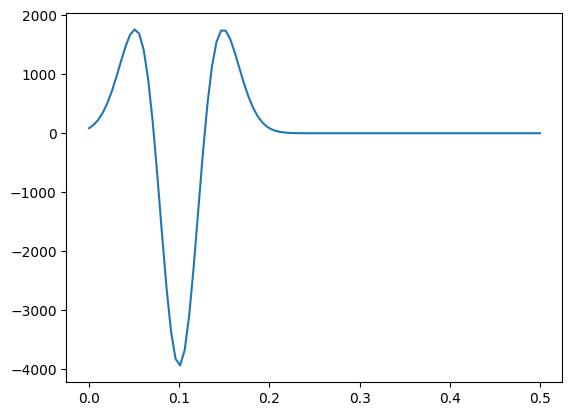

In [35]:
ts_ = np.linspace(0, 0.5, 100)
Fs = F(ts_)

print((np.diff(ts_)[0] * Fs).sum())

plt.plot(ts_, Fs)

## Experiment parameters

In [36]:
rho = 1.0
xlim = 8.0
ylim = 2.0

cp = 2.2
gamma = 0.4593
cs = gamma * cp

mu = cs**2 * rho
L = (cp**2 * rho) - 2 * mu

## Standard

In [51]:
poly_order = 5
ny = 20
nx = 4 * ny

In [156]:
importlib.reload(elastic_wave_ader_standard)

# cfl = 0.5 * 0.5 / (2 * 5 + 1)
# cfl = 0.9 * 0.5 / (2 * poly_order + 1)
cfl = 0.03
dx = (xlim / nx)
dt = cfl * dx / (np.sqrt((L + 2 * mu) / rho))

std_solver = elastic_wave_ader_standard.ElasticWaveStandardAderDG2D(
    xlim, ylim, nx, ny, poly_order=poly_order, rho=rho, mu=mu, L=L, dt=dt, 
    y_periodic=False
)

xs = std_solver.xs[:, :, 0]
ys = std_solver.ys[:, :, 0]

# u, v, oxx, oyy, oxy = std_solver.get_vars(std_solver.state)
# oxy[:] = np.exp(-(xs - 5)**2 -(ys - 5)**2)

std_ader_times = [std_solver.time]
std_ader_states = [np.copy(std_solver.state)]

In [157]:
%%time
while std_solver.time < 1.0:
    std_solver.time_step(forcing_func=f)

std_ader_times.append(std_solver.time)
std_ader_states.append(np.copy(std_solver.state))

CPU times: user 4min 18s, sys: 1min 22s, total: 5min 41s
Wall time: 46.3 s


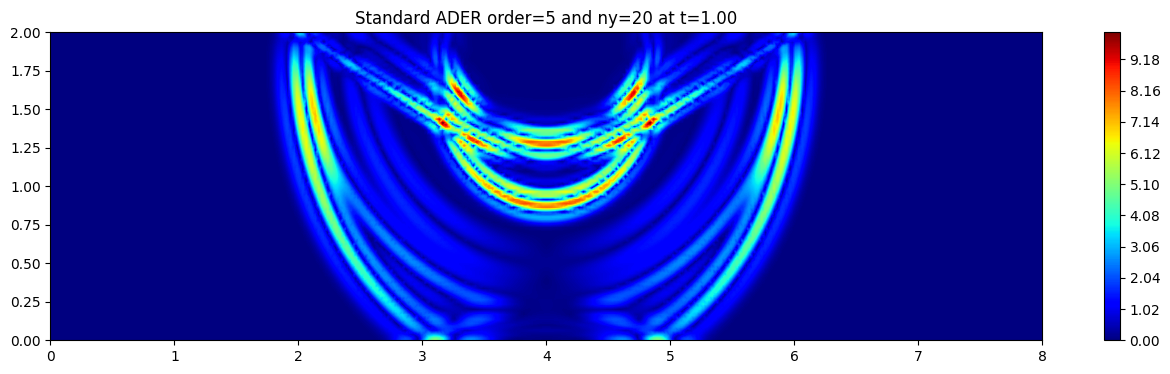

In [158]:
mask = abs(xs.ravel() - 4) < 20
idx = 1
u, v, oxx, oyy, oxy = std_solver.get_vars(std_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'Standard ADER order={std_solver.poly_order} and ny={std_solver.ny} at t={std_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [9]:
while std_solver.time < 2.0:
    std_solver.time_step(forcing_func=f)

std_ader_times.append(std_solver.time)
std_ader_states.append(np.copy(std_solver.state))

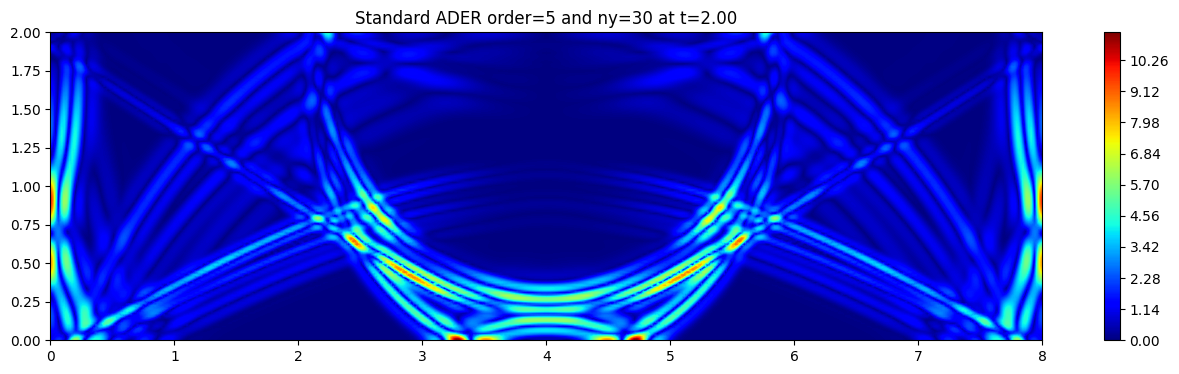

In [10]:
mask = abs(xs.ravel() - 4) < 20
idx = 2
u, v, oxx, oyy, oxy = std_solver.get_vars(std_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'Standard ADER order={std_solver.poly_order} and ny={std_solver.ny} at t={std_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [11]:
while std_solver.time < 3.0:
    std_solver.time_step(forcing_func=f)

std_ader_times.append(std_solver.time)
std_ader_states.append(np.copy(std_solver.state))

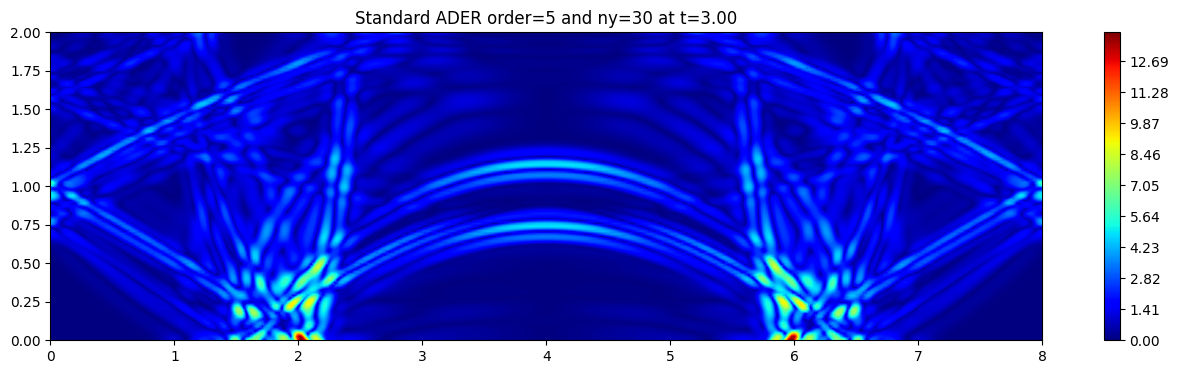

In [12]:
mask = abs(xs.ravel() - 4) < 20
idx = 3
u, v, oxx, oyy, oxy = std_solver.get_vars(std_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'Standard ADER order={std_solver.poly_order} and ny={std_solver.ny} at t={std_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

## New ADER

In [603]:
poly_order = 5
ny = 30
nx = 4 * ny

In [16]:
importlib.reload(elastic_wave_ader)

if poly_order == 3:
    cfl = 0.9 * 0.7
elif poly_order == 4:
    cfl = 0.9 * 0.44
elif poly_order == 5:
    cfl = 0.9 * 0.33
else:
    raise NotImplementedError

dx = (xlim / nx)
dt = cfl * dx / (np.sqrt((L + 2 * mu) / rho))
nsteps = int(1.0 / dt) + 1
dt = 1.0 / nsteps


solver = elastic_wave_ader.ElasticWaveAderDG2D(xlim, ylim, nx, ny, poly_order=poly_order, rho=rho, mu=mu, L=L, dt=dt, y_periodic=False)

xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]

In [593]:
new_ader_times = [solver.time]
new_ader_states = [np.copy(solver.state)]

In [595]:
%%time
for _ in range(nsteps):
    solver.time_step(forcing_func=f)

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))

CPU times: user 4min 28s, sys: 1min 26s, total: 5min 54s
Wall time: 49.3 s


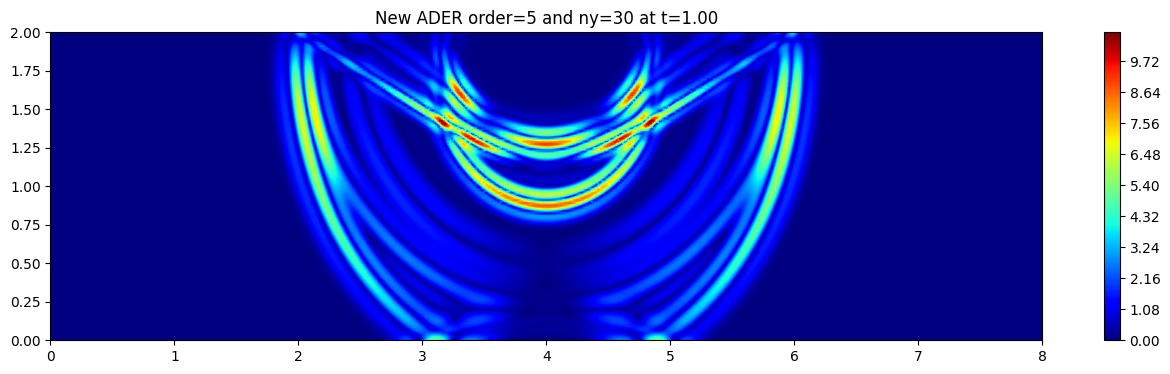

In [597]:
mask = abs(xs.ravel() - 4) < 20
idx = 1
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [596]:
%%time
for _ in range(nsteps):
    solver.time_step(forcing_func=f)

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))

CPU times: user 4min 34s, sys: 1min 18s, total: 5min 52s
Wall time: 49.6 s


In [590]:
# new_ader_times

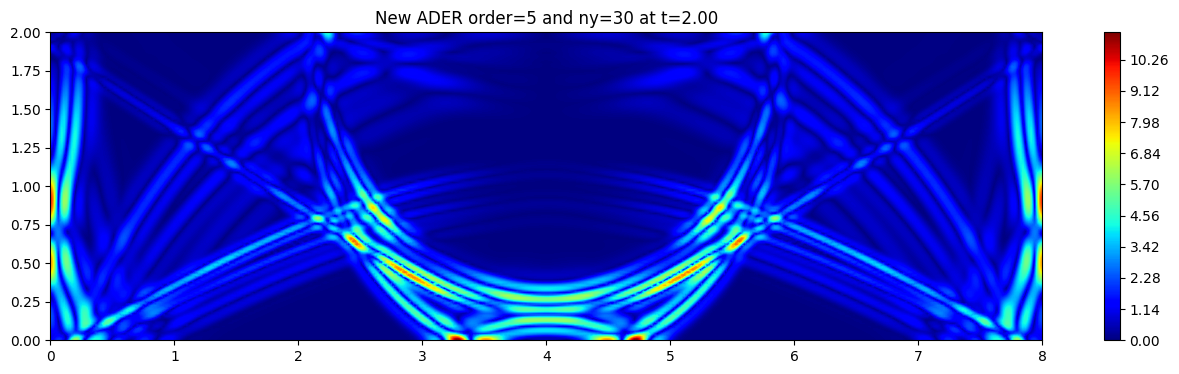

In [598]:
mask = abs(xs.ravel() - 4) < 20
idx = 2
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [599]:
%%time
for _ in range(nsteps):
    solver.time_step(forcing_func=f)

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))

CPU times: user 4min 23s, sys: 1min 25s, total: 5min 49s
Wall time: 48.2 s


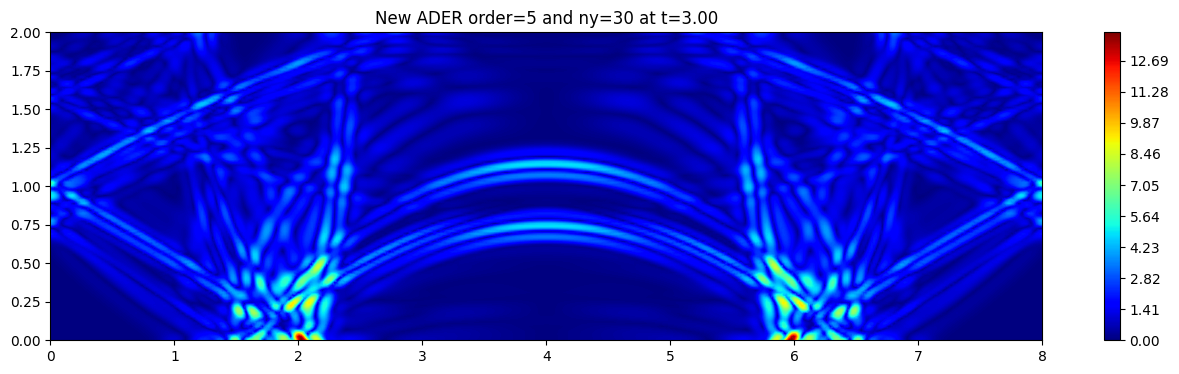

In [600]:
mask = abs(xs.ravel() - 4) < 20
idx = 3
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [28]:
N = 20
rhs_in = std_solver.get_rhs(std_solver.state)

t0 = time.time()
for _ in range(N):
    std_solver.time_step()

print((time.time() - t0) / N)

0.118030846118927


In [29]:
t0 = time.time()
for _ in range(N):
    bdry_integrals = std_solver.corrector(rhs_in)

print((time.time() - t0) / N)

0.03319724798202515


In [21]:
t0 = time.time()
for _ in range(N):
    diff = (bdry_integrals * std_solver.weights_x[None, None, None, :, None, None]).sum(axis=3)

print((time.time() - t0) / N)

0.007680904865264892


In [17]:
N = 20
rhs_in = solver.get_rhs(solver.state)

t0 = time.time()
for _ in range(N):
    solver.preconditioner(rhs_in)

print((time.time() - t0) / N)

0.05888808965682983
